In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")
sns.set_theme(style="whitegrid")

df = pd.read_csv(
    r"D:\PRO2291_DuAnTopNghiep\PRO2291_duantotnghiep1\data\cleaned\sales_cleaned.csv",
    low_memory=False
)



# Discount Distribution

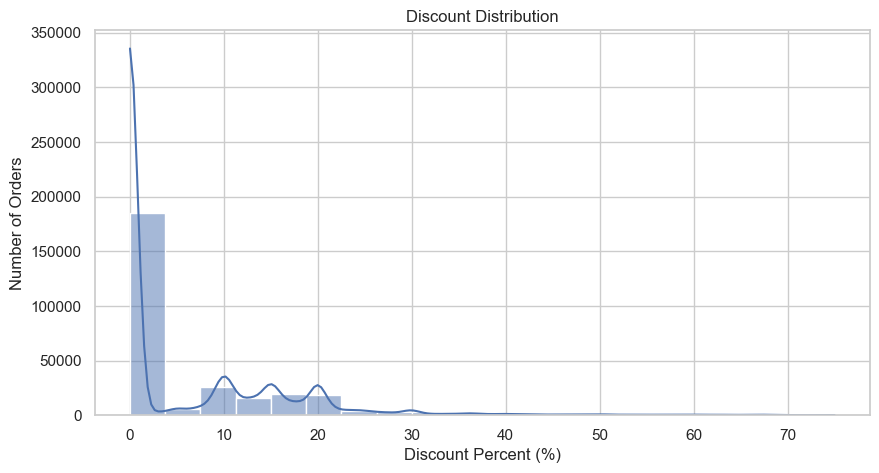

In [8]:
plt.figure(figsize=(10,5))

sns.histplot(
    df["discount_percent"],
    bins=20,
    kde=True
)

plt.title("Discount Distribution")
plt.xlabel("Discount Percent (%)")
plt.ylabel("Number of Orders")

plt.show()

# Revenue by Discount Group

In [9]:
def discount_group(x):

    if x == 0:
        return "0%"

    elif x <= 10:
        return "0-10%"

    elif x <= 20:
        return "10-20%"

    elif x <= 50:
        return "20-50%"

    else:
        return "50%+"

df["discount_group"] = (
    df["discount_percent"]
    .apply(discount_group)
)

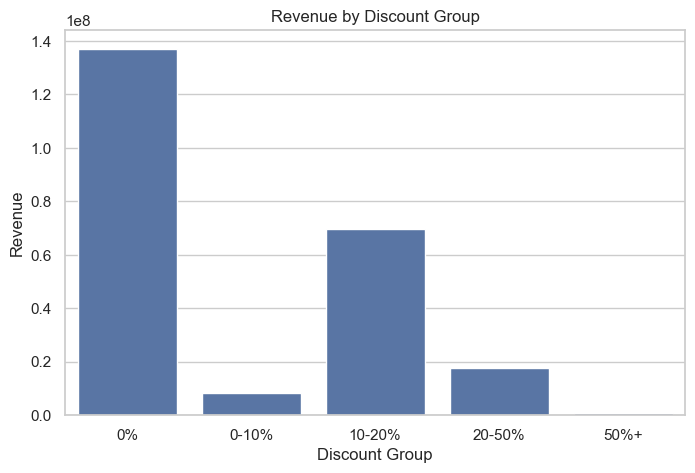

In [10]:
discount_revenue = (
    df.groupby("discount_group")["total"]
    .sum()
    .reindex(
        ["0%", "0-10%", "10-20%", "20-50%", "50%+"]
    )
)

plt.figure(figsize=(8,5))

sns.barplot(
    x=discount_revenue.index,
    y=discount_revenue.values
)

plt.title("Revenue by Discount Group")
plt.xlabel("Discount Group")
plt.ylabel("Revenue")

plt.show()

# Discount vs Revenue

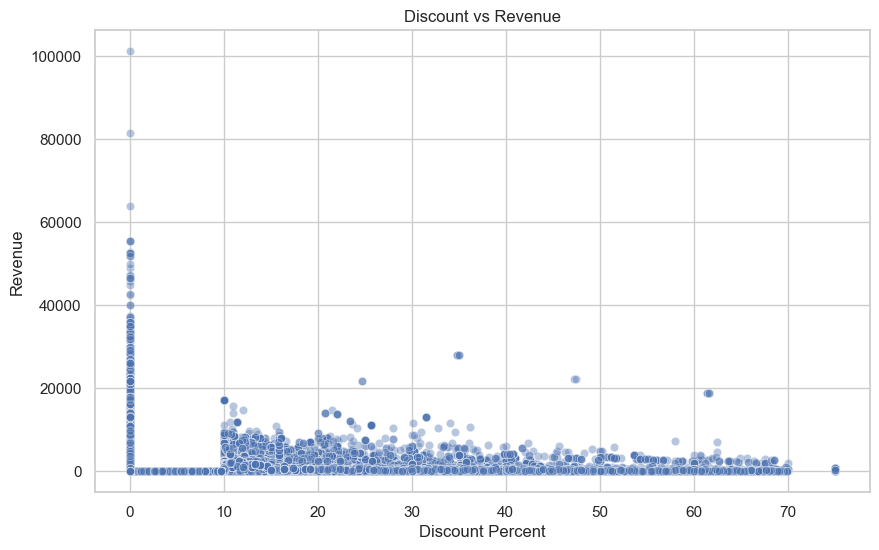

In [11]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x="discount_percent",
    y="total",
    alpha=0.4
)

plt.title("Discount vs Revenue")
plt.xlabel("Discount Percent")
plt.ylabel("Revenue")

plt.show()

# Payment Method Distribution

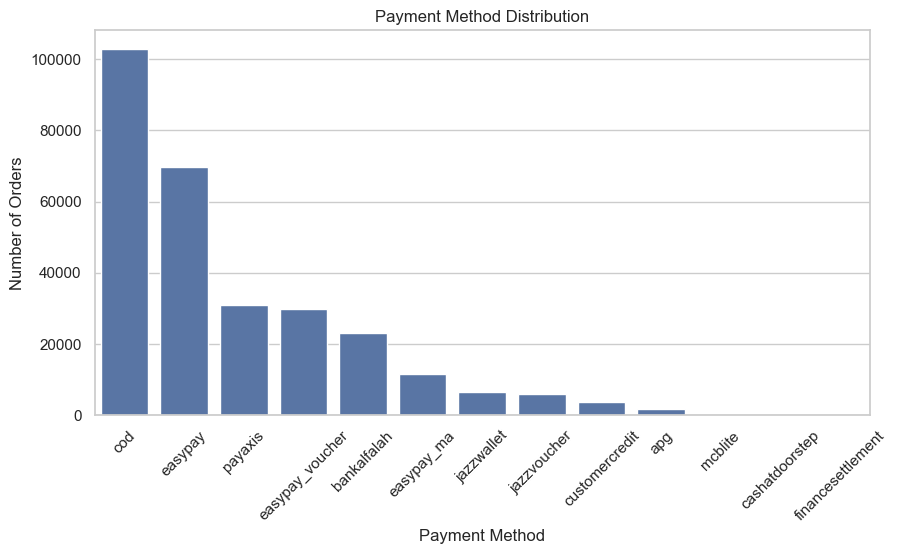

In [12]:
payment_count = (
    df["payment_method"]
    .value_counts()
)

plt.figure(figsize=(10,5))

sns.barplot(
    x=payment_count.index,
    y=payment_count.values
)

plt.title("Payment Method Distribution")
plt.xlabel("Payment Method")
plt.ylabel("Number of Orders")

plt.xticks(rotation=45)

plt.show()

# Revenue by Payment Method

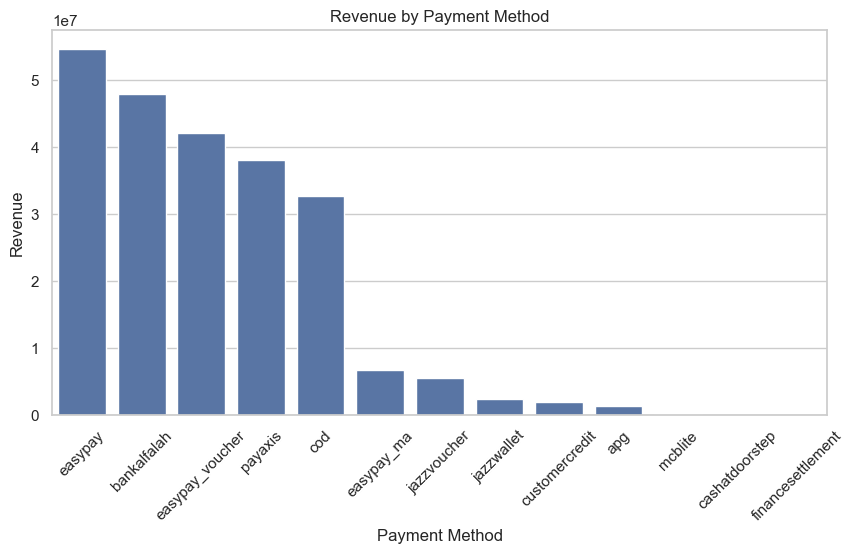

In [13]:
payment_revenue = (
    df.groupby("payment_method")["total"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10,5))

sns.barplot(
    x=payment_revenue.index,
    y=payment_revenue.values
)

plt.title("Revenue by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Revenue")

plt.xticks(rotation=45)

plt.show()

# dashboad 

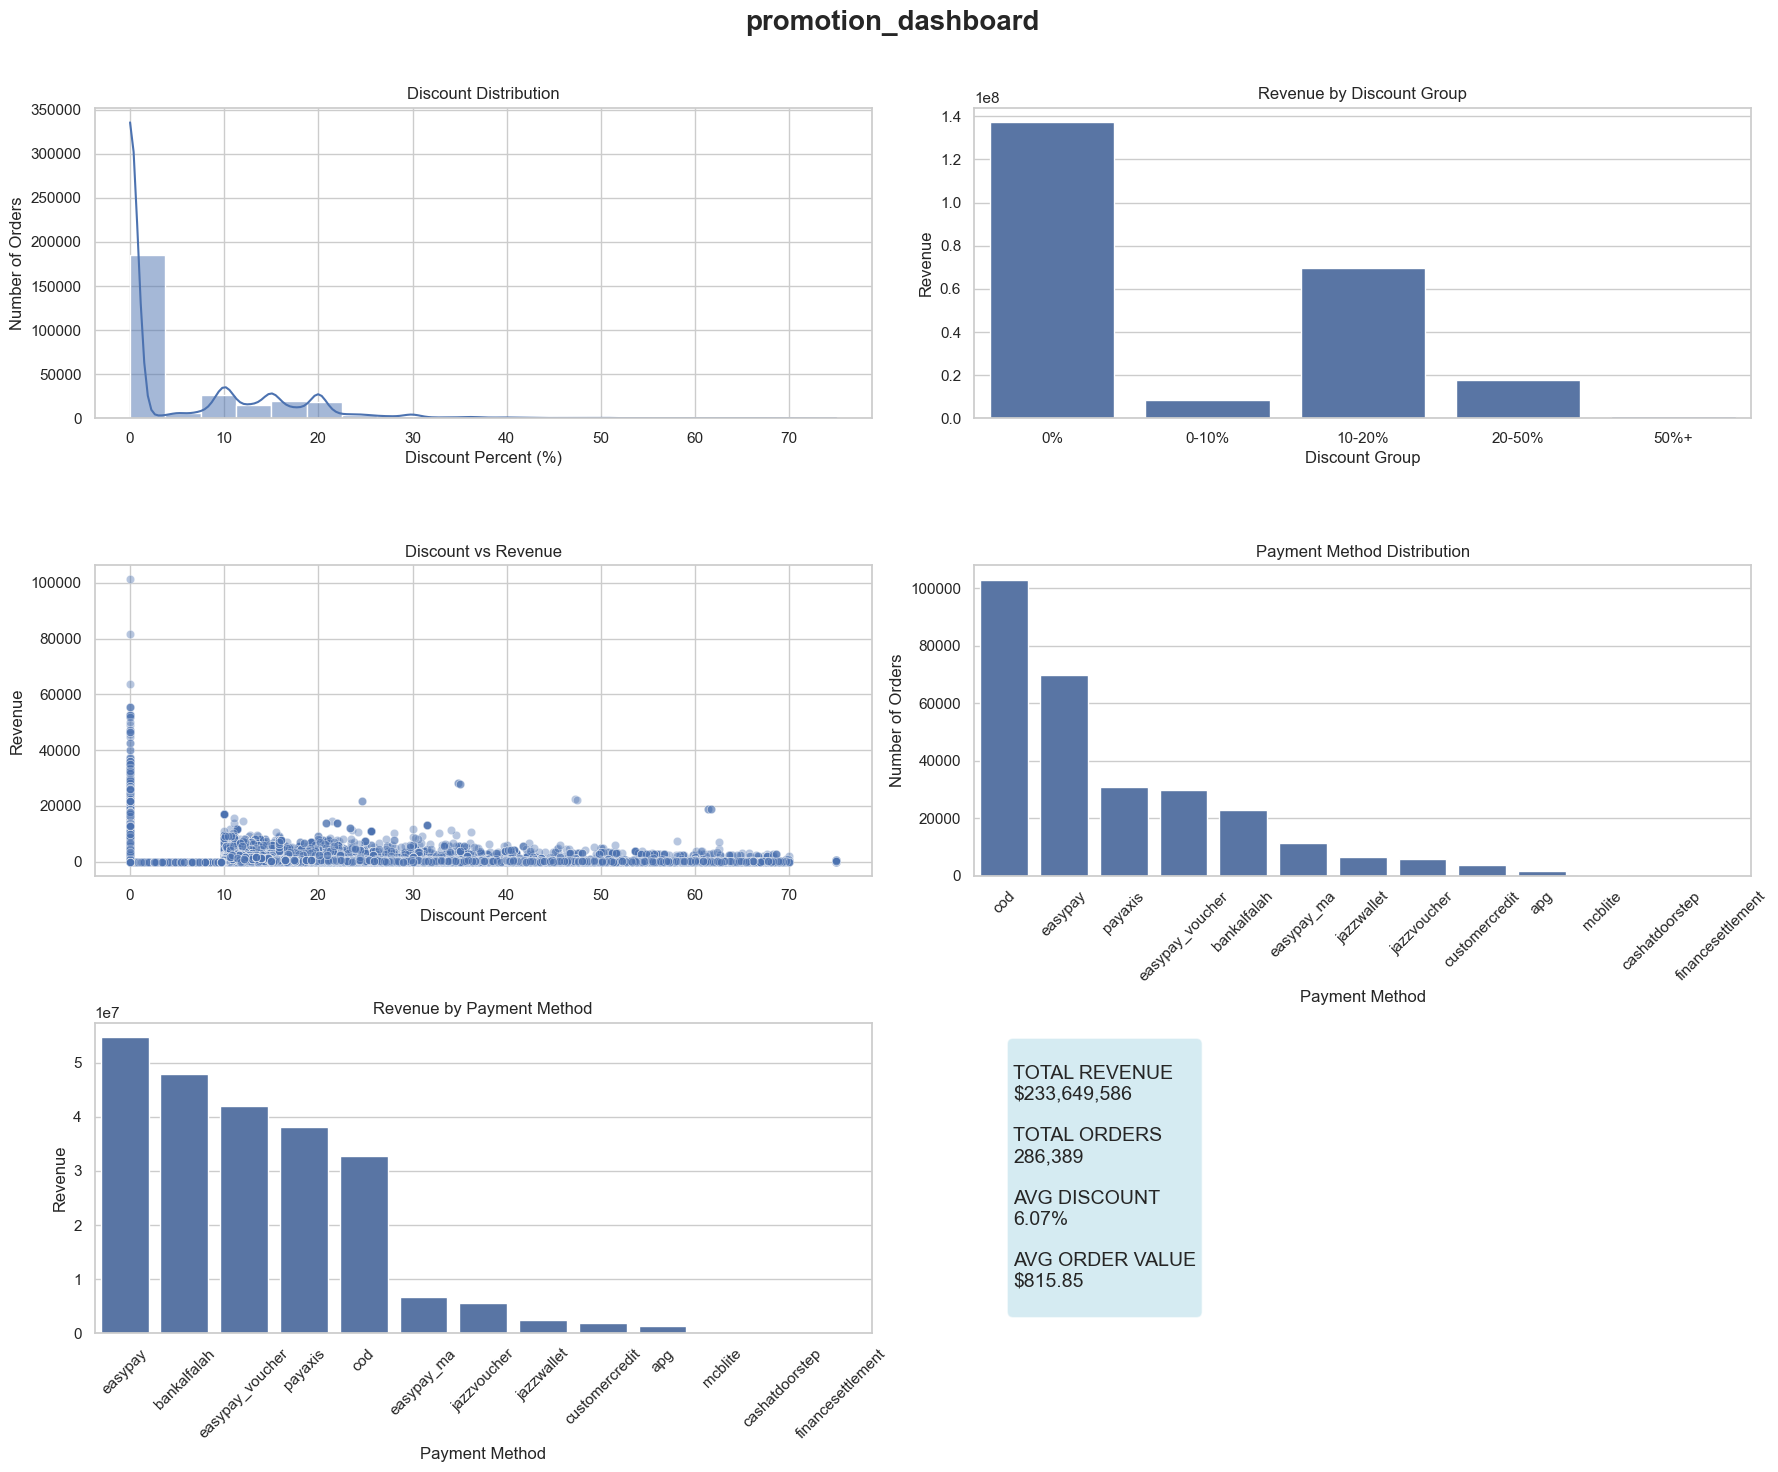

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns



def discount_group(x):
    if x == 0:
        return "0%"
    elif x <= 10:
        return "0-10%"
    elif x <= 20:
        return "10-20%"
    elif x <= 50:
        return "20-50%"
    else:
        return "50%+"

df["discount_group"] = df["discount_percent"].apply(discount_group)

discount_revenue = (
    df.groupby("discount_group")["total"]
      .sum()
      .reindex(["0%", "0-10%", "10-20%", "20-50%", "50%+"])
)

payment_count = df["payment_method"].value_counts()

payment_revenue = (
    df.groupby("payment_method")["total"]
      .sum()
      .sort_values(ascending=False)
)



fig, axes = plt.subplots(
    nrows=3,
    ncols=2,
    figsize=(18, 15)
)

fig.suptitle(
    "promotion_dashboard",
    fontsize=20,
    fontweight="bold"
)

sns.histplot(
    df["discount_percent"],
    bins=20,
    kde=True,
    ax=axes[0, 0]
)

axes[0, 0].set_title("Discount Distribution")
axes[0, 0].set_xlabel("Discount Percent (%)")
axes[0, 0].set_ylabel("Number of Orders")

sns.barplot(
    x=discount_revenue.index,
    y=discount_revenue.values,
    ax=axes[0, 1]
)

axes[0, 1].set_title("Revenue by Discount Group")
axes[0, 1].set_xlabel("Discount Group")
axes[0, 1].set_ylabel("Revenue")


sns.scatterplot(
    data=df,
    x="discount_percent",
    y="total",
    alpha=0.4,
    ax=axes[1, 0]
)

axes[1, 0].set_title("Discount vs Revenue")
axes[1, 0].set_xlabel("Discount Percent")
axes[1, 0].set_ylabel("Revenue")

sns.barplot(
    x=payment_count.index,
    y=payment_count.values,
    ax=axes[1, 1]
)

axes[1, 1].set_title("Payment Method Distribution")
axes[1, 1].set_xlabel("Payment Method")
axes[1, 1].set_ylabel("Number of Orders")
axes[1, 1].tick_params(axis="x", rotation=45)


sns.barplot(
    x=payment_revenue.index,
    y=payment_revenue.values,
    ax=axes[2, 0]
)

axes[2, 0].set_title("Revenue by Payment Method")
axes[2, 0].set_xlabel("Payment Method")
axes[2, 0].set_ylabel("Revenue")
axes[2, 0].tick_params(axis="x", rotation=45)


axes[2, 1].axis("off")

total_revenue = df["total"].sum()
total_orders = len(df)
avg_discount = df["discount_percent"].mean()
avg_order_value = df["total"].mean()

kpi_text = f"""
TOTAL REVENUE
${total_revenue:,.0f}

TOTAL ORDERS
{total_orders:,}

AVG DISCOUNT
{avg_discount:.2f}%

AVG ORDER VALUE
${avg_order_value:,.2f}
"""

axes[2, 1].text(
    0.05,
    0.5,
    kpi_text,
    fontsize=14,
    verticalalignment="center",
    bbox=dict(boxstyle="round", facecolor="lightblue", alpha=0.5)
)

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()